In [1]:
import pygimli as pg 
import matplotlib.pyplot as plt
import numpy as np
from pygimli.physics import ert
import pygimli.meshtools as mt
from scipy.interpolate import griddata
import pandas as pd
import os 
output_dir = "inversion4"
os.makedirs(output_dir, exist_ok=True)

29/03/26 - 20:11:47 - pyGIMLi - WARNING - Keyword argument changed from 'cmap' to 'cMap' and will be removed in v 
29/03/26 - 20:11:47 - pyGIMLi - INFO - Cache c:\Users\sider\.conda\envs\pg\Lib\site-packages\pygimli\physics\ert\ert.py:createGeometricFactors restored (0.0s x 113): C:\Users\sider\AppData\Roaming\pygimli\Cache\17970140561219481632


Data: Sensors: 21 data: 171, nonzero entries: ['a', 'b', 'k', 'm', 'n', 'valid']


29/03/26 - 20:11:48 - pyGIMLi - INFO - Data error estimate (min:max)  0.05000646492989695 : 0.05498040002706264
29/03/26 - 20:11:48 - pyGIMLi - INFO - 0.662636985614011 1229.5566691596337
29/03/26 - 20:11:48 - pyGIMLi - INFO - Simulated data:  Data: Sensors: 21 data: 171, nonzero entries: ['a', 'b', 'err', 'i', 'k', 'm', 'n', 'r', 'rhoa', 'u', 'valid']
29/03/26 - 20:11:48 - pyGIMLi - INFO - The data contains :  ['a', 'b', 'err', 'i', 'ip', 'iperr', 'k', 'm', 'n', 'r', 'rhoa', 'u', 'valid']
29/03/26 - 20:11:48 - pyGIMLi - INFO - Sim rhoa (min/max) :  57.690391453248104 140.35602680087445
29/03/26 - 20:11:48 - pyGIMLi - INFO - Selected data noise % (min/ma)x :  5.000646492989695 5.498040002706264
29/03/26 - 20:11:48 - pyGIMLi - INFO - filtered rhoa minmax dd :  57.690391453248104 140.35602680087445


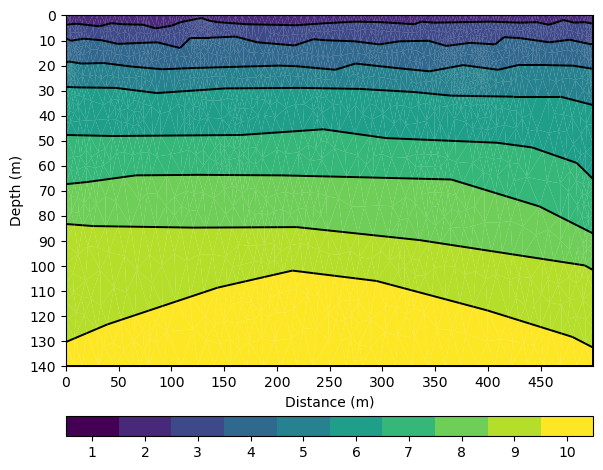

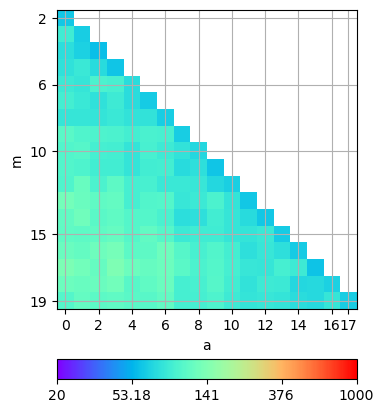

In [2]:
world=mt.createWorld(start=[-1000,0],end=[1500,-1000],worldMarker=1)
poly=mt.createRectangle(start=[0, -140], end=[500, 0], marker=1)

interfaces = []

for i in range(9):
    coords = np.loadtxt(f'shape_{i}.txt')
    line = mt.createPolygon(coords, isClosed=False)
    interfaces.append(line)

geom = mt.mergePLC([world] + interfaces + [poly])

geom.addRegionMarker(pos=[0, -1], marker=2)
geom.addRegionMarker(pos=[0, -6], marker=3)
geom.addRegionMarker(pos=[0, -12], marker=4)
geom.addRegionMarker(pos=[0, -23], marker=5)
geom.addRegionMarker(pos=[0, -40], marker=6)
geom.addRegionMarker(pos=[0, -60], marker=7)
geom.addRegionMarker(pos=[0, -80], marker=8)
geom.addRegionMarker(pos=[0, -100], marker=9)
geom.addRegionMarker(pos=[0, -140], marker=10)


mesh_cut = mt.createMesh(geom, quality=34)

x_min,x_max= 0,500
y_min,y_max= -140,0

ax, cbar = pg.show(mesh_cut, data=mesh_cut.cellMarkers(), 
                   showMesh=False, aspect='auto', 
                   cmap=plt.get_cmap("viridis", 10))
cbar.mappable.set_clim(0.5, 10.5)
cbar.set_ticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

ax.set_xlim(0, 500)
ax.set_ylim(-140, 0)
ax.set_yticks(np.arange(-140, 1, 10)) 
ax.set_xticks(np.arange(0, 500, 50)) 
ax.set_xlabel("Distance (m)")   
ax.set_ylabel("Depth (m)")
ax.figure.savefig(os.path.join(output_dir, f'mesh_cut.png'))
#plt.draw()


spacing=25
scheme=ert.createData(
    elecs=np.linspace(start=0,stop=500,num=len(np.arange(0,501,spacing)))
    , schemeName='dd'
)
print(scheme)
for p in scheme.sensors():
    geom.createNode(p)
    geom.createNode(p-[0,0.1]) # create 2  nodes for FTDT
mesh_fwr=mt.createMesh(geom,quality=34)
rhomap=[[1,100],
        [2,100],
        [3,30],
        [4,200],
        [5,100],
        [6,50],
        [7,80],
        [8,150],
        [9,300],
        [10,400]
        ] # resistivity for each region
#pg.show(mesh_fwr,data=rhomap,label=pg.unit('res'), cMap='gist_rainbow',logScale=True,aspect='auto')

data=ert.simulate(mesh_fwr,scheme=scheme, res=rhomap, noiseLevel=0.05, noiseAbs=1e-6, seed=1337)

pg.info(np.linalg.norm(data['err']),np.linalg.norm(data['rhoa']))
pg.info('Simulated data: ',data)
pg.info('The data contains : ',data.dataMap().keys())
pg.info('Sim rhoa (min/max) : ' ,min(data['rhoa']), max(data['rhoa']))
pg.info('Selected data noise % (min/ma)x : ', min(data['err'])*100, max(data['err'])*100)

data.remove(data['rhoa']<0)
pg.info('filtered rhoa minmax dd : ', min(data['rhoa']), max(data['rhoa']))

os.makedirs(output_dir, exist_ok=True) #Make new dir to save files

data.save(os.path.join(output_dir, f'{output_dir}_dd.dat'))

#ert.show(data,cMap='rainbow',cMin=20,cMax=1000,logScale=True,title='DD')   #pseudosection
pg.viewer.mpl.showDataContainerAsMatrix(data,'a','m', 'rhoa',cMap='rainbow',cMin=20,cMax=1000,logScale=True,title='DD')

np.save(os.path.join(output_dir, f'{output_dir}_abmn_dd.npy'), np.column_stack([data['a'], data['b'], data['m'], data['n']]))
np.save(os.path.join(output_dir, f'{output_dir}_res_all_dd.npy'), np.column_stack([data['rhoa']]))
abmn_data_dd = np.load(os.path.join(output_dir, f'{output_dir}_abmn_dd.npy'))
res_data_dd=np.load(os.path.join(output_dir, f'{output_dir}_res_all_dd.npy')) 

In [3]:
def fill_nan(image):
    image=image.copy()
    nan_mask = np.isnan(image)
    mean_value = np.nanmean(image)
    image[nan_mask] = mean_value
    return image, nan_mask

def compress(image, n_pixels, z_factor,rank): 
    image, nan_mask = fill_nan(image)
    U, S, Vt = np.linalg.svd(image, full_matrices=False)
    rank=len(S) if rank is None else rank
    U_reduced = U[:, :rank]
    S_reduced = S[:rank]
    Vt_reduced = Vt[:rank, :]
    compressed_image = np.dot(U_reduced, np.dot(np.diag(S_reduced), Vt_reduced))
    contributions = np.abs(U_reduced)  @ np.diag(S_reduced) @ np.abs(Vt_reduced)
    
    # Apply depth weighting to contributions
    rows, cols = np.arange(image.shape[0]), np.arange(image.shape[1])
    z = rows / np.max(rows)
    depth_weight = 1 + z_factor * z   
    depth_weight = depth_weight[:, None]
    contributions *= depth_weight

    contributions[nan_mask] = -np.inf

    #anchor points
    #first column (idx= 0)
    valid_rows_0 = np.flatnonzero(~nan_mask[:, 0])
    if valid_rows_0.size > 0:
        rows_min, rows_max, rows_mean = valid_rows_0[0], valid_rows_0[-1],valid_rows_0[valid_rows_0.size // 2]
        contributions[rows_min, 0],contributions[rows_max, 0], contributions[rows_mean, 0] = np.inf, np.inf, np.inf
    
    #set last column first row contribution to inf
    valid_cols= np.where(~nan_mask)[1]
    if valid_cols.size > 0:
        col_last = valid_cols.max()
        valid_rows_in_last_col = np.flatnonzero(~nan_mask[:, col_last])
        if valid_rows_in_last_col.size > 0:
            row_last = valid_rows_in_last_col[0]
            contributions[row_last, col_last] = np.inf

        unique_cols = np.unique(valid_cols)
        col_mean = unique_cols[unique_cols.size // 2]
        valid_rows_in_mean_col = np.flatnonzero(~nan_mask[:, col_mean])
        if valid_rows_in_mean_col.size > 0:
            contributions[valid_rows_in_mean_col[-1], col_mean] = np.inf

    flat_indices = np.argsort(contributions.flatten())[::-1][:n_pixels]
    significant_indices = np.unravel_index(flat_indices, image.shape)
    return compressed_image, significant_indices, nan_mask, contributions,rank

def reconstruct(image_shape, significant_indices, pixel_values):
    # Create an empty image with the given shape
    compressed_image = np.full(image_shape, np.nan)
    # Assign the provided pixel values to the significant indices
    compressed_image[significant_indices] = pixel_values
    # Interpolate to fill in the missing values
    x, y = np.meshgrid(np.arange(image_shape[1]), np.arange(image_shape[0]))
    mask = ~np.isnan(compressed_image)
    interpolated_image = griddata(
        (x[mask], y[mask]),  # Points with known values
        compressed_image[mask],  # Known values
        (x, y),  # Points to interpolate
        method='linear'  # Interpolation 
        )
    return interpolated_image
def plot_ert_checkerboard(data,plot=0):
    #Extract unique electrode positions
    electrodes = np.unique(data[['A', 'B', 'M', 'N']].values)
    electrode_map = {electrode: idx for idx, electrode in enumerate(sorted(electrodes))}
    #Create a grid
    grid_size = len(electrode_map)
    heatmap = np.full((grid_size, grid_size), np.nan)
    #Map values to the grid
    for _, row in data.iterrows():
        x = electrode_map[row['A']]
        y = electrode_map[row['M']]
        heatmap[y, x] = row['Res']
    if plot==1:
        #Plot the checkerboard heatmap
        plt.figure(figsize=(10, 8))
        plt.imshow(np.log10(heatmap), cmap='gist_rainbow', interpolation='nearest')
        plt.colorbar(label='ERT Measurement Value')
        plt.xticks(ticks=np.arange(grid_size), labels=sorted(electrode_map.keys()), rotation=90)
        plt.yticks(ticks=np.arange(grid_size), labels=sorted(electrode_map.keys()))
        plt.xlabel('Electrode A')
        plt.ylabel('Electrode N')
        plt.title('ERT Checkerboard Heatmap')
        plt.savefig(os.path.join(output_dir, f'{output_dir}_checkerboard_heatmap.png'))
        plt.close()
    return heatmap

29/03/26 - 20:11:50 - pyGIMLi - INFO - Found 2 regions.
29/03/26 - 20:11:50 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
29/03/26 - 20:11:50 - pyGIMLi - INFO - Found 2 regions.
29/03/26 - 20:11:50 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
29/03/26 - 20:11:50 - pyGIMLi - INFO - Creating forward mesh from region infos.
29/03/26 - 20:11:50 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
29/03/26 - 20:11:51 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 39734 Cells: 79012 Boundaries: 59486
29/03/26 - 20:11:51 - pyGIMLi - INFO - Use median(data values)=90.3603732272228
29/03/26 - 20:11:51 - pyGIMLi - INFO - Created startmodel from forward operator:17404, min/max=90.360373/90.360373
29/03/26 - 20:11:51 - pyGIMLi - INFO - Starting inversion.


fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x00000288A2F3E250>
Data transformation: Logarithmic LU transform, lower bound 0.0, upper bound 0.0
Model transformation: Logarithmic transform
min/max (data): 57.69/140
min/max (error): 5%/5.5%
min/max (start model): 90.36/90.36
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =   15.30
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =    1.48 (dPhi = 87.67%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =    1.16 (dPhi = 18.31%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =    1.14 (dPhi = 2.68%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 4 ... chi² =    1.14 (dPhi = 0.02%) lam: 20.0
###################################################

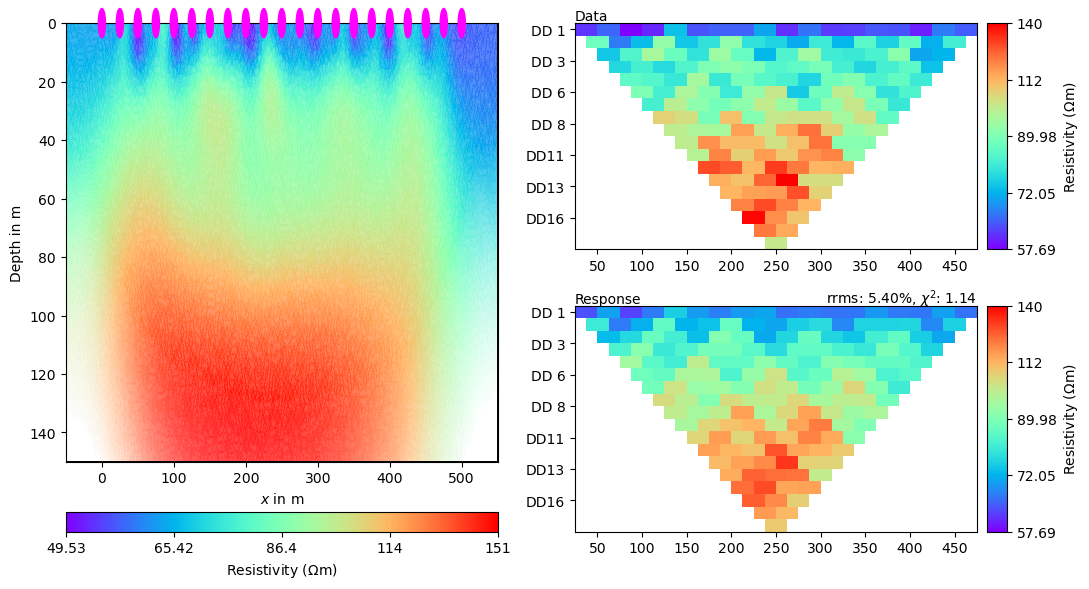

In [ ]:
abmn_data=np.load(os.path.join(output_dir, f'{output_dir}_abmn_dd.npy'))
res_data=np.load(os.path.join(output_dir, f'{output_dir}_res_all_dd.npy'))
data_all=np.column_stack((abmn_data, res_data))
data=pd.DataFrame(data_all, columns=['A', 'B', 'M', 'N', 'Res'])
image=plot_ert_checkerboard(data,plot=1)



mgr=ert.ERTManager(f'{output_dir}/{output_dir}_dd.dat')
mesh1=mgr.createMesh(quality=34,paraMaxCellSize=10 ,paraDepth=140)
inv1 = mgr.invert(mesh=mesh1,verbose=True)
res1=np.array(inv1)
np.save(os.path.join(output_dir, f'{output_dir}_res1.npy'), res1)

# Check that chi2 is below a reasonable threshold
assert mgr.inv.chi2() < 6000, f"DD chi2 too high: {mgr.inv.chi2()}" 
mgr.showResultAndFit(vmin=1, vmax=1000, cMap='rainbow', logScale=True,aspect='auto')
meshPD1 = pg.Mesh(mgr.paraDomain) # Save copy of para mesh for plotting later
ax,cbar = pg.show(mgr.paraDomain, inv1, label=pg.unit('res'), cMap='rainbow', logScale=True, vmin=1, vmax=1000,aspect='auto')
ax.figure.savefig(os.path.join(output_dir, f'{output_dir}_inversion_result.png'))
plt.close(ax.figure)
chi2_1=mgr.inv.chi2()

np.save(os.path.join(output_dir, f'{output_dir}_chi2_1.npy'), chi2_1)

In [ ]:

n_pixels=image[~np.isnan(image)].size
z_factor=0
rank=None
electrodes = np.unique(data[['A', 'B', 'M', 'N']].values)
electrode_map = {electrode: idx for idx, electrode in enumerate(sorted(electrodes))}
pixels_kept=[]
new_rhoa_list=[]
res2_list=[] #inversion results for resistivity (compressed)
chi2_2_list=[] #inversion chi2 values (compressed)


for n in np.arange(n_pixels, 20, -n_pixels//10):
    compressed_image, significant_indices, nan_mask, contributions, _ = compress(image, n, z_factor,rank)
    pixel_values = compressed_image[significant_indices]
    real_values = image[significant_indices]
    reconstructed_image = reconstruct(image.shape, significant_indices, pixel_values)
    predicted_values = reconstructed_image[significant_indices]
    pixels_kept.append(n)

    new_rhoa = []
    for _, row in data.iterrows():
        x=electrode_map[row['A']]
        y=electrode_map[row['M']]
    
    
        val=reconstructed_image[y, x]
        new_rhoa.append(val)

    new_rhoa=np.array(new_rhoa)
    np.save(f'{output_dir}/{output_dir}_reconstructed{n}.npy', new_rhoa)
    new_rhoa_list.append(new_rhoa)

    data_new=data.copy()
    data_new['Res'] = new_rhoa
    mgr2 = ert.ERTManager(f'{output_dir}/{output_dir}_dd.dat')
    mgr2.data['rhoa'] = new_rhoa
    mesh2 = mgr2.createMesh(quality=34, paraMaxCellSize=10, paraDepth=140)

    inv2 = mgr2.invert(mesh=mesh2, verbose=False)

    assert mgr2.inv.chi2() < 6000, f"DD chi2 too high: {mgr2.inv.chi2()}" 
    res2=np.array(inv2)
    res2_list.append(res2)
    chi2_2=mgr2.inv.chi2()
    chi2_2_list.append(chi2_2)

np.save(os.path.join(output_dir, f'{output_dir}_res2_list.npy'), np.array(res2_list))
np.save(os.path.join(output_dir, f'{output_dir}_chi2_2_list.npy'), np.array(chi2_2_list))

29/03/26 - 20:14:12 - pyGIMLi - INFO - Found 2 regions.
29/03/26 - 20:14:12 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
29/03/26 - 20:14:12 - pyGIMLi - INFO - Found 2 regions.
29/03/26 - 20:14:12 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
29/03/26 - 20:14:12 - pyGIMLi - INFO - Creating forward mesh from region infos.
29/03/26 - 20:14:12 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
29/03/26 - 20:14:13 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 39734 Cells: 79012 Boundaries: 59486
29/03/26 - 20:14:14 - pyGIMLi - INFO - Use median(data values)=90.36037322722274
29/03/26 - 20:16:32 - pyGIMLi - INFO - Found 2 regions.
29/03/26 - 20:16:32 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
29/03/26 - 20:16:32 - pyGIMLi - INFO - Found 2 regions.
29/03/26 - 20:16:32 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
29/03/26 - 20:16:32 - pyGIMLi 

29/03/26 - 20:24:24 - pyGIMLi - INFO - Found 2 regions.
29/03/26 - 20:24:24 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
29/03/26 - 20:24:24 - pyGIMLi - INFO - Found 2 regions.
29/03/26 - 20:24:24 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
29/03/26 - 20:24:24 - pyGIMLi - INFO - Creating forward mesh from region infos.
29/03/26 - 20:24:25 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
29/03/26 - 20:24:25 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 39734 Cells: 79012 Boundaries: 59486
29/03/26 - 20:24:26 - pyGIMLi - INFO - Use median(data values)=92.32628059296236
29/03/26 - 20:27:15 - pyGIMLi - INFO - Found 2 regions.
29/03/26 - 20:27:15 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
29/03/26 - 20:27:15 - pyGIMLi - INFO - Found 2 regions.
29/03/26 - 20:27:15 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
29/03/26 - 20:27:16 - pyGIMLi 

29/03/26 - 20:28:47 - pyGIMLi - INFO - Found 2 regions.
29/03/26 - 20:28:47 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
29/03/26 - 20:28:47 - pyGIMLi - INFO - Found 2 regions.
29/03/26 - 20:28:47 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
29/03/26 - 20:28:47 - pyGIMLi - INFO - Creating forward mesh from region infos.
29/03/26 - 20:28:48 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
29/03/26 - 20:28:49 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 39734 Cells: 79012 Boundaries: 59486
29/03/26 - 20:28:49 - pyGIMLi - INFO - Use median(data values)=90.91747266609732


29/03/26 - 20:30:20 - pyGIMLi - INFO - Found 2 regions.
29/03/26 - 20:30:20 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
29/03/26 - 20:30:21 - pyGIMLi - INFO - Found 2 regions.
29/03/26 - 20:30:21 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
29/03/26 - 20:30:21 - pyGIMLi - INFO - Creating forward mesh from region infos.
29/03/26 - 20:30:21 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
29/03/26 - 20:30:22 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 39734 Cells: 79012 Boundaries: 59486
29/03/26 - 20:30:23 - pyGIMLi - INFO - Use median(data values)=95.61518656665723


29/03/26 - 20:31:30 - pyGIMLi - INFO - Found 2 regions.
29/03/26 - 20:31:30 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
29/03/26 - 20:31:30 - pyGIMLi - INFO - Found 2 regions.
29/03/26 - 20:31:30 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
29/03/26 - 20:31:30 - pyGIMLi - INFO - Creating forward mesh from region infos.
29/03/26 - 20:31:31 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
29/03/26 - 20:31:32 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 39734 Cells: 79012 Boundaries: 59486
29/03/26 - 20:31:32 - pyGIMLi - INFO - Use median(data values)=91.66915808262408


In [9]:
for i in range(len(pixels_kept)):
    n = pixels_kept[i]
    res2 = res2_list[i]
    chi2_2 = chi2_2_list[i]

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 6))
    
    #riginal data
    pg.show(mgr.paraDomain, res1, label=pg.unit('res'), cMap='rainbow', logScale=True, cMin=40, cMax=150, aspect='equal', ax=ax1)
    ax1.set_title(f"Original Inversion\nChi2={chi2_1:.2f}%")
    
    #Compressed data
    pg.show(mgr.paraDomain, res2, label=pg.unit('res'), cMap='rainbow', logScale=True, cMin=40, cMax=150, aspect='equal', ax=ax2)
    ax2.set_title(f"Compressed Image Inversion Num. of pixels kept={n} \nChi2={chi2_2:.2f}%")

    #Difference Plot
    ax3.set_title("Difference Plot")
    diff_percent = np.abs(res1 / res2)
    pg.show(mgr.paraDomain, diff_percent, ax=ax3, cMap="bwr", cMin=0, cMax=2, label='Ratio (Original/Reconstructed)', aspect='equal')

    plt.tight_layout()  
    fig.savefig(os.path.join(output_dir, f'{output_dir}_comparison_{n}.png'))
    plt.close(fig)